## Stage 1 — Odds collection & vig removal
Pulls live NBA odds from The Odds API, strips the vig,
and computes consensus probabilities across all bookmakers.

In [1]:
!pip install requests

Importing and API setup

In [6]:
import requests
import pandas as pd
import json

API_KEY = "de954158190d8ddae5003a0584edf0b0"

response = requests.get(
    "https://api.the-odds-api.com/v4/sports/basketball_nba/odds",
    params={
        "apiKey": API_KEY,
        "regions": "us",
        "markets": "h2h",  # head to head (home / draw / away)
        "oddsFormat": "decimal"
    }
)

data = response.json()
print(json.dumps(data, indent=4))

[
    {
        "id": "b5dcac663f902f16c62d91c7552bd07a",
        "sport_key": "basketball_nba",
        "sport_title": "NBA",
        "commence_time": "2026-03-26T23:10:00Z",
        "home_team": "Charlotte Hornets",
        "away_team": "New York Knicks",
        "bookmakers": [
            {
                "key": "fanduel",
                "title": "FanDuel",
                "last_update": "2026-03-26T08:11:18Z",
                "markets": [
                    {
                        "key": "h2h",
                        "last_update": "2026-03-26T08:11:18Z",
                        "outcomes": [
                            {
                                "name": "Charlotte Hornets",
                                "price": 1.86
                            },
                            {
                                "name": "New York Knicks",
                                "price": 1.98
                            }
                        ]
                    }
        

In [7]:
print(f"{len(data)} games found")

5 games found


Game 1

In [8]:
game = data[0]
print(game["home_team"], "vs", game["away_team"])
print("Date:", game["commence_time"])

Charlotte Hornets vs New York Knicks
Date: 2026-03-26T23:10:00Z


In [12]:
for i in range(len(game["bookmakers"])):
  book = game["bookmakers"][i]
  print(f"\nBookmaker: {book['title']}")
  for outcome in book["markets"][0]["outcomes"]:
      implied_prob = 1 / outcome["price"]
      print(f"  {outcome['name']}: {outcome['price']} odds = {implied_prob:.1%}")


Bookmaker: FanDuel
  Charlotte Hornets: 1.86 odds = 53.8%
  New York Knicks: 1.98 odds = 50.5%

Bookmaker: MyBookie.ag
  Charlotte Hornets: 1.88 odds = 53.2%
  New York Knicks: 1.93 odds = 51.8%

Bookmaker: DraftKings
  Charlotte Hornets: 1.87 odds = 53.5%
  New York Knicks: 1.95 odds = 51.3%

Bookmaker: BetRivers
  Charlotte Hornets: 1.89 odds = 52.9%
  New York Knicks: 1.89 odds = 52.9%

Bookmaker: BetOnline.ag
  Charlotte Hornets: 1.87 odds = 53.5%
  New York Knicks: 1.95 odds = 51.3%

Bookmaker: LowVig.ag
  Charlotte Hornets: 1.88 odds = 53.2%
  New York Knicks: 1.97 odds = 50.8%

Bookmaker: BetMGM
  Charlotte Hornets: 1.87 odds = 53.5%
  New York Knicks: 1.95 odds = 51.3%

Bookmaker: BetUS
  Charlotte Hornets: 1.87 odds = 53.5%
  New York Knicks: 1.95 odds = 51.3%

Bookmaker: Bovada
  Charlotte Hornets: 1.83 odds = 54.6%
  New York Knicks: 2.0 odds = 50.0%


Strip out the vig (bookmaker's built-in profit margin) and normalise the probabilities

In [13]:
def normalize_odds(bookmaker):
    outcomes = bookmaker["markets"][0]["outcomes"]

    # raw implied probabilities
    raw_probs = {o["name"]: 1 / o["price"] for o in outcomes}

    # total adds up to > 1 because of vig
    total = sum(raw_probs.values())
    vig = (total - 1) * 100

    # normalize so they sum to exactly 100%
    clean_probs = {name: prob / total for name, prob in raw_probs.items()}

    return clean_probs, vig

# ------------------------------------------------------------------------

# Run it across all bookmakers
for book in game["bookmakers"]:
    probs, vig = normalize_odds(book)
    print(f"\n{book['title']} (vig: {vig:.1f}%)")
    for team, prob in probs.items():
        print(f"  {team}: {prob:.1%}")


FanDuel (vig: 4.3%)
  Charlotte Hornets: 51.6%
  New York Knicks: 48.4%

MyBookie.ag (vig: 5.0%)
  Charlotte Hornets: 50.7%
  New York Knicks: 49.3%

DraftKings (vig: 4.8%)
  Charlotte Hornets: 51.0%
  New York Knicks: 49.0%

BetRivers (vig: 5.8%)
  Charlotte Hornets: 50.0%
  New York Knicks: 50.0%

BetOnline.ag (vig: 4.8%)
  Charlotte Hornets: 51.0%
  New York Knicks: 49.0%

LowVig.ag (vig: 4.0%)
  Charlotte Hornets: 51.2%
  New York Knicks: 48.8%

BetMGM (vig: 4.8%)
  Charlotte Hornets: 51.0%
  New York Knicks: 49.0%

BetUS (vig: 4.8%)
  Charlotte Hornets: 51.0%
  New York Knicks: 49.0%

Bovada (vig: 4.6%)
  Charlotte Hornets: 52.2%
  New York Knicks: 47.8%


Finding market average

In [14]:
from collections import defaultdict

team_probs = defaultdict(list)

for book in game["bookmakers"]:
    probs, _ = normalize_odds(book)
    for team, prob in probs.items():
        team_probs[team].append(prob)

print("Consensus probabilities (market average):")
for team, probs in team_probs.items():
    consensus = sum(probs) / len(probs)
    print(f"  {team}: {consensus:.1%}  (range: {min(probs):.1%} – {max(probs):.1%})")

Consensus probabilities (market average):
  Charlotte Hornets: 51.1%  (range: 50.0% – 52.2%)
  New York Knicks: 48.9%  (range: 47.8% – 50.0%)


Going through all the games in our earlier data

In [15]:
rows = []

for game in data:
    team_probs = defaultdict(list)

    for book in game["bookmakers"]:
        probs, _ = normalize_odds(book)
        for team, prob in probs.items():
            team_probs[team].append(prob)

    teams = list(team_probs.keys())

    for team in teams:
        probs = team_probs[team]
        rows.append({
            "game": f"{game['home_team']} vs {game['away_team']}",
            "team": team,
            "consensus_prob": sum(probs) / len(probs),
            "min_prob": min(probs),
            "max_prob": max(probs),
            "spread": max(probs) - min(probs),
            "num_books": len(probs),
            "commence_time": game["commence_time"]
        })

df = pd.DataFrame(rows)
df = df.sort_values("spread", ascending=False)
print(df.to_string(index=False))

                                   game                 team  consensus_prob  min_prob  max_prob   spread  num_books        commence_time
   Charlotte Hornets vs New York Knicks      New York Knicks        0.489116  0.477807  0.500000 0.022193          9 2026-03-26T23:10:00Z
   Charlotte Hornets vs New York Knicks    Charlotte Hornets        0.510884  0.500000  0.522193 0.022193          9 2026-03-26T23:10:00Z
Detroit Pistons vs New Orleans Pelicans      Detroit Pistons        0.647077  0.636145  0.656325 0.020180          9 2026-03-26T23:10:00Z
Detroit Pistons vs New Orleans Pelicans New Orleans Pelicans        0.352923  0.343675  0.363855 0.020180          9 2026-03-26T23:10:00Z
      Orlando Magic vs Sacramento Kings        Orlando Magic        0.889853  0.881057  0.896318 0.015261          9 2026-03-26T23:10:00Z
      Orlando Magic vs Sacramento Kings     Sacramento Kings        0.110147  0.103682  0.118943 0.015261          9 2026-03-26T23:10:00Z
        Boston Celtics vs Atlanta 

Visualising

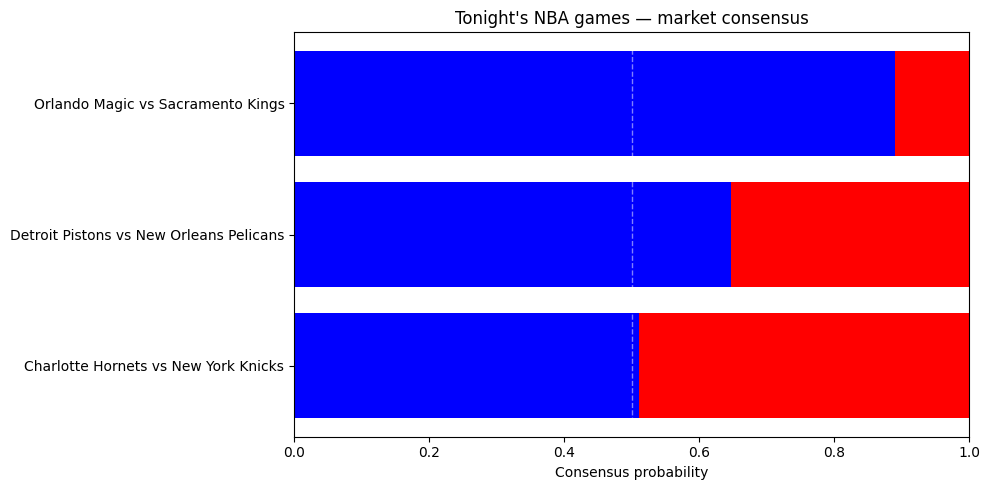

In [17]:
import matplotlib.pyplot as plt

# filter to games with more than 1 book
df_reliable = df[df["num_books"] > 1].copy()

# keep just one row per game (home team)
home_teams = df_reliable[df_reliable.apply(
    lambda r: r["team"] == r["game"].split(" vs ")[0], axis=1
)]

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in home_teams.iterrows():
    away_team = df_reliable[
        (df_reliable["game"] == row["game"]) &
        (df_reliable["team"] != row["team"])
    ].iloc[0]

    label = f"{row['team']} vs {away_team['team']}"
    ax.barh(label, row["consensus_prob"], color="blue", label="Home")
    ax.barh(label, away_team["consensus_prob"],
            left=row["consensus_prob"], color="red")

ax.axvline(0.5, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Consensus probability")
ax.set_title("Tonight's NBA games — market consensus")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Making the graph better

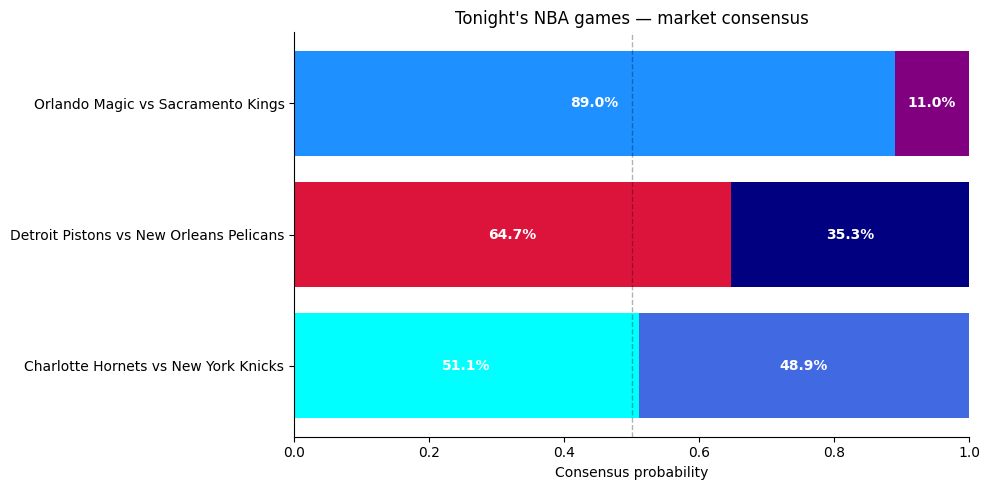

In [19]:
TEAM_COLORS = {
    "Charlotte Hornets": "cyan",
    "New York Knicks": "royalblue",
    "Detroit Pistons": "crimson",
    "New Orleans Pelicans": "navy",
    "Orlando Magic": "dodgerblue",
    "Sacramento Kings": "purple",
}

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in home_teams.iterrows():
    away = df_reliable[
        (df_reliable["game"] == row["game"]) &
        (df_reliable["team"] != row["team"])
    ].iloc[0]

    home_color = TEAM_COLORS.get(row["team"], "#888888")
    away_color = TEAM_COLORS.get(away["team"], "#aaaaaa")
    label = f"{row['team']} vs {away['team']}"

    ax.barh(label, row["consensus_prob"], color=home_color)
    ax.barh(label, away["consensus_prob"], left=row["consensus_prob"], color=away_color)

    # probability labels inside bars
    ax.text(row["consensus_prob"] / 2, label,
            f"{row['consensus_prob']:.1%}", va="center", ha="center",
            color="white", fontsize=10, fontweight="bold")
    ax.text(row["consensus_prob"] + away["consensus_prob"] / 2, label,
            f"{away['consensus_prob']:.1%}", va="center", ha="center",
            color="white", fontsize=10, fontweight="bold")

ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.3)
ax.set_xlabel("Consensus probability")
ax.set_title("Tonight's NBA games — market consensus")
ax.set_xlim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Stage 2 — Historical data & team stats

NBA Standings data

In [20]:
import pandas as pd

url = "https://www.basketball-reference.com/leagues/NBA_2026_standings.html"
tables = pd.read_html(url)

# eastern and western conference standings
east = tables[0]
west = tables[1]

print("Eastern Conference:")
print(east[["Eastern Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].head(10))
print("\nWestern Conference:")
print(west[["Western Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].head(10))

Eastern Conference:
        Eastern Conference   W   L   W/L%   PS/G   PA/G
0      Detroit Pistons (1)  52  19  0.732  117.3  109.5
1       Boston Celtics (2)  47  24  0.662  114.1  107.0
2      New York Knicks (3)  48  25  0.658  117.2  110.5
3  Cleveland Cavaliers (4)  45  27  0.625  119.2  114.9
4      Toronto Raptors (5)  40  31  0.563  114.2  112.3
5        Atlanta Hawks (6)  40  32  0.556  118.3  116.4
6   Philadelphia 76ers (7)  39  33  0.542  115.6  116.2
7        Orlando Magic (8)  38  34  0.528  115.7  114.8
8    Charlotte Hornets (9)  38  34  0.528  116.4  111.8
9          Miami Heat (10)  38  34  0.528  120.2  117.5

Western Conference:
           Western Conference   W   L   W/L%   PS/G   PA/G
0   Oklahoma City Thunder (1)  57  15  0.792  118.7  107.5
1       San Antonio Spurs (2)  54  18  0.750  119.2  111.7
2      Los Angeles Lakers (3)  46  26  0.639  116.4  114.9
3          Denver Nuggets (4)  45  28  0.616  120.9  116.5
4  Minnesota Timberwolves (5)  44  28  0.611  11

Combining conferences

In [21]:
import re

def clean_team_name(name):
    return re.sub(r"\s*\(\d+\)", "", name).strip()

east = east[["Eastern Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].copy()
west = west[["Western Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].copy()

east.columns = ["team", "W", "L", "win_pct", "pts_scored", "pts_allowed"]
west.columns = ["team", "W", "L", "win_pct", "pts_scored", "pts_allowed"]

east["conference"] = "East"
west["conference"] = "West"

standings = pd.concat([east, west], ignore_index=True)
standings["team"] = standings["team"].apply(clean_team_name)

# add a simple net rating (offensive - defensive strength)
standings["net_pts"] = standings["pts_scored"] - standings["pts_allowed"]

print(standings[["team", "win_pct", "pts_scored", "pts_allowed", "net_pts"]]
      .sort_values("net_pts", ascending=False)
      .to_string(index=False))

                  team  win_pct  pts_scored  pts_allowed  net_pts
 Oklahoma City Thunder    0.792       118.7        107.5     11.2
       Detroit Pistons    0.732       117.3        109.5      7.8
     San Antonio Spurs    0.750       119.2        111.7      7.5
        Boston Celtics    0.662       114.1        107.0      7.1
       New York Knicks    0.658       117.2        110.5      6.7
     Charlotte Hornets    0.528       116.4        111.8      4.6
        Denver Nuggets    0.616       120.9        116.5      4.4
   Cleveland Cavaliers    0.625       119.2        114.9      4.3
       Houston Rockets    0.606       114.2        110.2      4.0
Minnesota Timberwolves    0.611       118.4        114.5      3.9
            Miami Heat    0.528       120.2        117.5      2.7
       Toronto Raptors    0.563       114.2        112.3      1.9
         Atlanta Hawks    0.556       118.3        116.4      1.9
    Los Angeles Lakers    0.639       116.4        114.9      1.5
          

### (v1) Initial Prediction Model

When two teams play, the one with the better net rating should win more often.

Using the difference in net points between teams to estimate win probability

In [22]:
from scipy.special import expit  # sigmoid function

# Typically, home team is preferred by 2.5 - 3.5 points if 2 equal teams are playing
def predict_win_prob(home_team, away_team, standings, home_advantage=3.0):
    home = standings[standings["team"] == home_team].iloc[0]
    away = standings[standings["team"] == away_team].iloc[0]

    # difference in net rating + home court advantage
    diff = (home["net_pts"] - away["net_pts"]) + home_advantage

    # convert to probability using sigmoid
    # scaling factor 0.15 maps point diff to a reasonable probability range
    prob_home = expit(diff * 0.15)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "model_home_prob": prob_home,
        "model_away_prob": 1 - prob_home
    }

# test on tonight's games
games = [
    ("Charlotte Hornets", "New York Knicks"),
    ("Detroit Pistons", "New Orleans Pelicans"),
    ("Orlando Magic", "Sacramento Kings"),
]

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    print(f"\n{pred['home_team']} vs {pred['away_team']}")
    print(f"  Model:  {pred['home_team']} {pred['model_home_prob']:.1%} | {pred['away_team']} {pred['model_away_prob']:.1%}")


Charlotte Hornets vs New York Knicks
  Model:  Charlotte Hornets 53.4% | New York Knicks 46.6%

Detroit Pistons vs New Orleans Pelicans
  Model:  Detroit Pistons 89.8% | New Orleans Pelicans 10.2%

Orlando Magic vs Sacramento Kings
  Model:  Orlando Magic 89.5% | Sacramento Kings 10.5%


Comparing with market consensus

In [23]:
# pull consensus probs for tonight's games into a lookup
consensus_lookup = {}
for _, row in df_reliable.iterrows():
    consensus_lookup[(row["game"], row["team"])] = row["consensus_prob"]

print(f"{'Game':<45} {'Team':<25} {'Model':>8} {'Market':>8} {'Edge':>8}")
print("-" * 100)

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    game_key = f"{home} vs {away}"

    for team, model_prob in [(home, pred["model_home_prob"]), (away, pred["model_away_prob"])]:
        market_prob = consensus_lookup.get((game_key, team), None)
        if market_prob:
            edge = model_prob - market_prob
            edge_str = f"+{edge:.1%}" if edge > 0 else f"{edge:.1%}"
            print(f"{game_key:<45} {team:<25} {model_prob:>7.1%} {market_prob:>7.1%} {edge_str:>8}")

Game                                          Team                         Model   Market     Edge
----------------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks          Charlotte Hornets           53.4%   51.1%    +2.3%
Charlotte Hornets vs New York Knicks          New York Knicks             46.6%   48.9%    -2.3%
Detroit Pistons vs New Orleans Pelicans       Detroit Pistons             89.8%   64.7%   +25.1%
Detroit Pistons vs New Orleans Pelicans       New Orleans Pelicans        10.2%   35.3%   -25.1%
Orlando Magic vs Sacramento Kings             Orlando Magic               89.5%   89.0%    +0.5%
Orlando Magic vs Sacramento Kings             Sacramento Kings            10.5%   11.0%    -0.5%


Orlando vs Sacramento is almost perfect agreement — both your model and the market see it as roughly 89/11. That's a good sign

Charlotte vs Knicks is a small +2.3% edge for Charlotte — our model is slightly more bullish on the home team than the market, likely because of home advantage combined with similar net ratings

But Detroit at +25.1% is the loud signal here. Our model thinks Detroit should be ~90% favorites, but the market only has them at 64.7%.

That's a massive gap and almost certainly means something our model doesn't know about — most likely injuries or rest.

The market prices in real-time information; our model only knows season-long averages.

### Adding an injury context check

In [24]:
# check what the market is implying vs our model
# a huge gap usually means missing context

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    game_key = f"{home} vs {away}"

    home_market = consensus_lookup.get((game_key, home))
    model_home = pred["model_home_prob"]
    gap = abs(model_home - home_market)

    if gap > 0.10:
        print(f"Large gap detected: {game_key}")
        print(f"Model: {model_home:.1%} | Market: {home_market:.1%} | Gap: {gap:.1%}")
        print(f"Check injuries/rest for both teams before trusting this edge\n")

Large gap detected: Detroit Pistons vs New Orleans Pelicans
Model: 89.8% | Market: 64.7% | Gap: 25.1%
Check injuries/rest for both teams before trusting this edge



### Key limitation discovered
Model uses season averages only — does not account for:
- Injuries / player availability
- Back-to-back fatigue
- Recent form vs season-long averages

Large gaps between model and market (>15%) almost always
indicate missing context, not genuine betting edge.

Replacing season-long averages with recent form (last 10 games)

In [32]:
def get_recent_form(team_slug, season=2026, n_games=10):
    url = f"https://www.basketball-reference.com/teams/{team_slug}/{season}/gamelog"
    tables = pd.read_html(url)

    gl = tables[0]

    # flatten multi-index columns
    if isinstance(gl.columns, pd.MultiIndex):
        gl.columns = [' '.join(col).strip() for col in gl.columns]

    # filter to real games only
    gl = gl[gl["Unnamed: 0_level_0 Rk"].apply(lambda x: str(x).isdigit())].copy()

    gl["pts_scored"] = pd.to_numeric(gl["Score Tm"], errors="coerce")
    gl["pts_allowed"] = pd.to_numeric(gl["Score Opp"], errors="coerce")
    gl = gl.dropna(subset=["pts_scored", "pts_allowed"])

    recent = gl.tail(n_games)

    return {
        "pts_scored": recent["pts_scored"].mean(),
        "pts_allowed": recent["pts_allowed"].mean(),
        "net_pts": (recent["pts_scored"] - recent["pts_allowed"]).mean()
    }

In [33]:
TEAM_SLUGS = {
    "Charlotte Hornets": "CHO",
    "New York Knicks": "NYK",
    "Detroit Pistons": "DET",
    "New Orleans Pelicans": "NOP",
    "Orlando Magic": "ORL",
    "Sacramento Kings": "SAC",
    "Boston Celtics": "BOS",
    "Cleveland Cavaliers": "CLE",
    "Oklahoma City Thunder": "OKC",
    "San Antonio Spurs": "SAS",
    "Los Angeles Lakers": "LAL",
    "Denver Nuggets": "DEN",
    "Minnesota Timberwolves": "MIN",
    "Houston Rockets": "HOU",
    "Phoenix Suns": "PHO",
    "Los Angeles Clippers": "LAC",
    "Portland Trail Blazers": "POR",
    "Golden State Warriors": "GSW",
    "Philadelphia 76ers": "PHI",
    "Atlanta Hawks": "ATL",
    "Miami Heat": "MIA",
    "Toronto Raptors": "TOR",
    "Memphis Grizzlies": "MEM",
    "Chicago Bulls": "CHI",
    "Dallas Mavericks": "DAL",
    "Milwaukee Bucks": "MIL",
    "Utah Jazz": "UTA",
    "Indiana Pacers": "IND",
    "Brooklyn Nets": "BRK",
    "Washington Wizards": "WAS",
}

In [34]:
for home, away in games:
    for team in [home, away]:
        slug = TEAM_SLUGS[team]
        form = get_recent_form(slug)
        print(f"{team} (last 10): scored {form['pts_scored']:.1f} | allowed {form['pts_allowed']:.1f} | net {form['net_pts']:+.1f}")
    print()

Charlotte Hornets (last 10): scored 118.3 | allowed 106.1 | net +12.2
New York Knicks (last 10): scored 119.7 | allowed 108.6 | net +11.1

Detroit Pistons (last 10): scored 119.3 | allowed 108.9 | net +10.4
New Orleans Pelicans (last 10): scored 119.4 | allowed 112.8 | net +6.6

Orlando Magic (last 10): scored 120.7 | allowed 119.7 | net +1.0
Sacramento Kings (last 10): scored 114.4 | allowed 121.6 | net -7.2



### (v2) Improved prediction model

In [35]:
def predict_win_prob_v2(home_team, away_team, home_advantage=3.0):
    home_form = get_recent_form(TEAM_SLUGS[home_team])
    away_form = get_recent_form(TEAM_SLUGS[away_team])

    diff = (home_form["net_pts"] - away_form["net_pts"]) + home_advantage
    prob_home = expit(diff * 0.15)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "model_v1": None,  # season average (filled below)
        "model_v2": prob_home,
        "model_v2_away": 1 - prob_home
    }

print(f"{'Game':<45} {'Team':<25} {'V1 (season)':>12} {'V2 (last 10)':>12} {'Market':>8} {'Edge':>8}")
print("-" * 115)

for home, away in games:
    v1 = predict_win_prob(home, away, standings)
    v2 = predict_win_prob_v2(home, away)
    game_key = f"{home} vs {away}"

    for team, v1_prob, v2_prob in [
        (home, v1["model_home_prob"], v2["model_v2"]),
        (away, v1["model_away_prob"], v2["model_v2_away"])
    ]:
        market = consensus_lookup.get((game_key, team))
        edge = v2_prob - market
        edge_str = f"+{edge:.1%}" if edge > 0 else f"{edge:.1%}"
        print(f"{game_key:<45} {team:<25} {v1_prob:>11.1%} {v2_prob:>11.1%} {market:>7.1%} {edge_str:>8}")
    print()

Game                                          Team                       V1 (season) V2 (last 10)   Market     Edge
-------------------------------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks          Charlotte Hornets               53.4%       64.9%   51.1%   +13.8%
Charlotte Hornets vs New York Knicks          New York Knicks                 46.6%       35.1%   48.9%   -13.8%

Detroit Pistons vs New Orleans Pelicans       Detroit Pistons                 89.8%       73.5%   64.7%    +8.8%
Detroit Pistons vs New Orleans Pelicans       New Orleans Pelicans            10.2%       26.5%   35.3%    -8.8%

Orlando Magic vs Sacramento Kings             Orlando Magic                   89.5%       84.3%   89.0%    -4.7%
Orlando Magic vs Sacramento Kings             Sacramento Kings                10.5%       15.7%   11.0%    +4.7%



### Model v2 limitations
- Recent form can be noisy over just 10 games
- Doesn't account for injuries (Murray/Murphy questionable tonight)
- Doesn't know opponent strength during that 10-game stretch
- A team can look good recently by playing weak opponents

---------------

Waiting for tonight's games and then comparing our models with the actual game outcomes.

---------------